In [1]:
import numpy as np
import glob, os
import matplotlib.pyplot as plt
from copy import deepcopy

In [2]:
base_dict = {"VAE_RMSD": None,
             "VAE_LOSS_RMSD": None,
             "PCA_RMSD": None,
             "PCA_LOSS_RMSD": None}

def load_files(numpy_files, verbose=True):
    fns = sorted(numpy_files)
    attrs = [fn.split('/')[1:] if fn.split('/')[0] == 'numpy_backups' else fn.split('/') for fn in fns]
    model_name = attrs[0][0]
    assert False not in [elem[0] == model_name for elem in attrs]
    
    model_data = {}
    for attr_set in attrs:
        n_latents = int(attr_set[1].split('_')[0])
        if n_latents not in model_data.keys():
            model_data[n_latents] = {}
        rpt = attr_set[2]
        if rpt not in model_data[n_latents].keys():
            model_data[n_latents][rpt] = deepcopy(base_dict)

        try:
            if attr_set[-1].split('.')[0] in [key for key in base_dict.keys()]:
                model_data[n_latents][rpt][attr_set[-1].split('.')[0]] = np.load(os.path.join(*attr_set))
            else:
                if verbose:
                    print(f"Excluding ", os.path.join(*attr_set))
        except:
            if verbose:
                    print(f"Failure on", os.path.join(*attr_set))
            
    return model_data

def lowest_rpts(chart_data):
    means = {}

    for key, val in chart_data.items():
        if key not in means.keys():
            means[key] = {}
        for key2, val2 in chart_data[key].items():
            if key2 not in means[key].keys():
                means[key][key2] = {}
            for key3, val3 in chart_data[key][key2].items():
                means[key][key2][key3] = np.mean(chart_data[key][key2][key3])
    
    best_rpts_RMSD = {key: None for key in means.keys()}
    best_rpts_LOSS = {key: None for key in means.keys()}
    
    for key, val in means.items():
        #discover the lowest mean rpt
        best_rpts_RMSD[key] = min(val.items(), key=lambda x: x[-1]['VAE_RMSD'])[0]
        best_rpts_LOSS[key] = min(val.items(), key=lambda x: x[-1]['VAE_LOSS_RMSD'])[0]
    
    return means, best_rpts_RMSD, best_rpts_LOSS

In [3]:
#Plot Violin of the best

def violin_plots(vae_dat, pca_dat, latents, title, ceil=10.0, num_stds=3, show=False, figure_dir=None, test_hists=False):
    import matplotlib.pyplot as plt

    figure_log = f"Log for making figure {title=} \n"
    
    #rmsds and pca rmsds are a dict of results with keys n_latent and vals hist_vals
    rpt_rmsds = [10*vae_dat[key] for key in vae_dat.keys()] #convert to angstrom
    rpt_pca_rmsds = [10*pca_dat[key] for key in pca_dat.keys()] #convert to angstrom
    og_shapes, og_pca_shapes = [data.shape[0] for data in rpt_rmsds], [data.shape[0] for data in rpt_pca_rmsds]
    
    #remove nan values
    rpt_rmsds = [data[np.where(~np.isnan(data))] for data in rpt_rmsds]
    rpt_pca_rmsds = [data[np.where(~np.isnan(data))] for data in rpt_pca_rmsds]
    non_nan_shapes, non_nan_pca_shapes = [data.shape[0] for data in rpt_rmsds], [data.shape[0] for data in rpt_pca_rmsds]

    #Report the number of Nan values, and remove datasets with all Nan values
    indices_all_nan = []
    for i, (latent, old1, old2, new1, new2) in enumerate(zip(latents, og_shapes, og_pca_shapes, non_nan_shapes, non_nan_pca_shapes)):
        if old1 - new1 > 0: #Not all of the frames were preserved from that latent
            figure_log += f"For model with {latent} Latents, \n \t {old1-new1} Nan values were found in VAE \n \t {old2 - new2} Nan values were found in PCA \n"
        if new1 == 0:
            indices_all_nan.append(i)

    #Now remove values above a ridiculous threshold, like 10 angstroms
    rpt_rmsds = [data[np.where(data < ceil)] for data in rpt_rmsds]
    rpt_pca_rmsds = [data[np.where(data < ceil)] for data in rpt_pca_rmsds]
    in_thresh_shapes, in_thresh_pca_shapes = [data.shape[0] for data in rpt_rmsds], [data.shape[0] for data in rpt_pca_rmsds]

    #Report the number of values above the threshold
    for i, (latent, old1, old2, new1, new2) in enumerate(zip(latents, non_nan_shapes, non_nan_pca_shapes, in_thresh_shapes, in_thresh_pca_shapes)):
        if old1 - new1 > 0: #Not all of the frames were preserved from that latent
            figure_log += f"For model with {latent} Latents, \n \t {old1-new1} values were found in VAE above the ceiling of {ceil} Angstroms \n \t {old2 - new2} Nan values were found in VAE above the ceiling of {ceil} Angstroms \n"

    #Retrim - all datasets should be composed of real values between 0 and ceil, remove empty sets now (if they were all nan essentiall)
    rpt_rmsds = [data for i, data in enumerate(rpt_rmsds) if i not in indices_all_nan]
    rpt_pca_rmsds = [data for i, data in enumerate(rpt_pca_rmsds) if i not in indices_all_nan]
    latents2plot = [data for i, data in enumerate(latents) if i not in indices_all_nan]
    
    #detect outliers - calculate median, std, and do not plot above n stds
    rpt_rmsd_medians = [np.median(arr) for arr in rpt_rmsds]
    rpt_rmsd_stds = [np.std(arr) for arr in rpt_rmsds]
    rpt_pca_rmsd_medians = [np.median(arr) for arr in rpt_pca_rmsds]
    rpt_pca_rmsd_stds = [np.std(arr) for arr in rpt_pca_rmsds]
    rpt_maxima = [median + 3*std for median, std in zip(rpt_rmsd_medians, rpt_rmsd_stds)]
    rpt_pca_maxima = [median + 3*std for median, std in zip(rpt_pca_rmsd_medians, rpt_pca_rmsd_stds)]
    
    figure_log += str([(median, std) for median, std in zip(rpt_rmsd_medians, rpt_rmsd_stds)])
    figure_log += '\n'
    
    #Reduce charting data to those within the threshold
    rpt_data2plot = [rpt_rmsd[np.where(rpt_rmsd < maximum)] for rpt_rmsd, maximum in zip(rpt_rmsds, rpt_maxima)]
    rpt_pca_data2plot = [rpt_pca_rmsd[np.where(rpt_pca_rmsd < maximum)] for rpt_pca_rmsd, maximum in zip(rpt_pca_rmsds, rpt_pca_maxima)]
    rpt_data2exclude = [np.where(rpt_rmsd > maximum)[0].shape for rpt_rmsd, maximum in zip(rpt_rmsds, rpt_maxima)]
    rpt_pca_data2exclude = [np.where(rpt_pca_rmsd > maximum)[0].shape for rpt_pca_rmsd, maximum in zip(rpt_pca_rmsds, rpt_pca_maxima)]
    
    plt.clf()
    fig = plt.figure(figsize=(3.25, 3.25))
    #Make the domain linear on n_latents = 1, 2, 3, 4 and log for 8, 16 etc
    domain = [n-0.05 if n <= 4 else 2+np.log2(n)-0.05 for n in latents2plot]
    v1 = plt.violinplot(rpt_data2plot, domain, showextrema=False)
    domain = [n+0.05 if n <= 4 else 2+np.log2(n)+0.05 for n in latents2plot]
    v2 = plt.violinplot(rpt_pca_data2plot, domain, showextrema=False)

    for i, b in enumerate(v1['bodies']):
        b.set_edgecolor('black')
        b.set_alpha(1)
        # get the center (the center is actually the domain point)
        m = np.mean(b.get_paths()[0].vertices[:, 0])
        # modify the paths to not go further right than the center
        b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], -np.inf, m)
        b.set_color('r')
        
    for b in v2['bodies']:
        b.set_edgecolor('black')
        b.set_alpha(1)
        # get the center
        m = np.mean(b.get_paths()[0].vertices[:, 0])
        # modify the paths to not go further left than the center
        b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], m, np.inf)
        b.set_color('b')
    
    #add some verticle lines where we excluded the NAN values, min and max set by the plotted data
    global_min = np.min([np.min(dataset) for dataset in rpt_data2plot])
    global_max = np.max([np.max(dataset) for dataset in rpt_data2plot])
    latents2vline = [n for n in latents if n not in latents2plot]
    latents2vline = [n-0.05 if n <= 4 else 2.05+np.log2(n) for n in latents2vline]
    
    plt.vlines(latents2vline, ymin=global_min, ymax=global_max,
              colors='red', linestyles='dashed')
    
    plt.xlabel('N_Latents')
    plt.ylabel('Reconstruction Error (Angstrom)')
    plt.title(title)
    #rotation = [0,0,0,0] + [45]*(len(latents)-4)
    plt.xticks(ticks=np.arange(1, len(latents)),
               labels=[''+str(latent) for latent in latents[:-1]],
               rotation='vertical', ha='left')
    
    plt.savefig(os.path.join(figure_dir, f'reconstruction_rmsd_{title=}.png'), bbox_inches='tight')
    if show:
        plt.show()

    figure_log += (f"Number of points that are {num_stds:0.3f} stds above the median \n")
    figure_log += (f"\t VAE = {rpt_data2exclude} \n")
    figure_log += (f"\t PCA = {rpt_pca_data2exclude} \n")

    with open(os.path.join(figure_dir, f'figure_generation_log.txt'), 'w') as f:
        f.write(figure_log)
    
    return fig, figure_log

In [4]:
def title_of_model(name):
    if name.startswith('OX_X'):
        return 'Oxycodone'
    elif name.startswith('DA_X'):
        return 'Deca-Alanine'
    elif name.startswith('DA_stretch'):
        return 'Deca-Alanine Helix Stretch'
    elif name.startswith('CR_X'):
        return 'Crambin'
    elif name.startswith('BR_X'):
        return 'BRD4/JQ1'
    elif name.startswith('HIV1p_X'):
        return 'HIV1-Protease'
    elif name.startswith('KOR_X'):
        return 'KOR/ak'
    else:
        raise Exception(f'No title found for {name}!')

In [5]:
base_models, model_prefixes = [f'X013-{i}' for i in [1, 2, 3, 4]], ['OX_', 'DA_', 'DA_stretch_', 'CR_', 'BR_']

In [6]:
#base_models, model_prefixes = ['X013-2', 'X013-4'], ['CR_']

OX_X013-1


<Figure size 640x480 with 0 Axes>

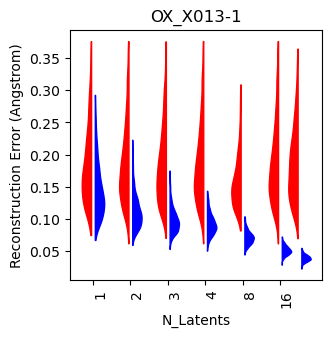

DA_X013-1


<Figure size 640x480 with 0 Axes>

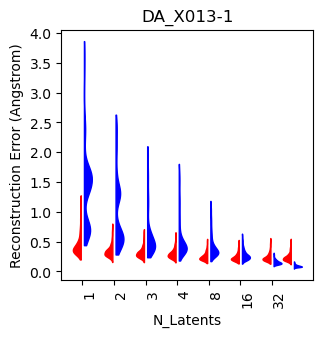

DA_stretch_X013-1


<Figure size 640x480 with 0 Axes>

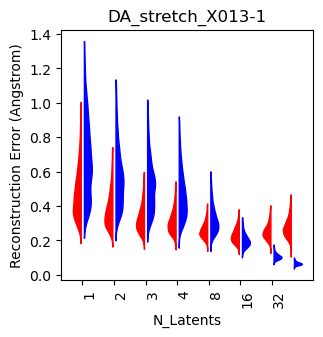

CR_X013-1


<Figure size 640x480 with 0 Axes>

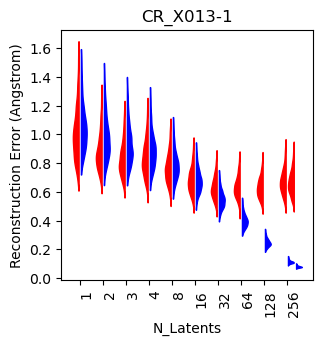

BR_X013-1


<Figure size 640x480 with 0 Axes>

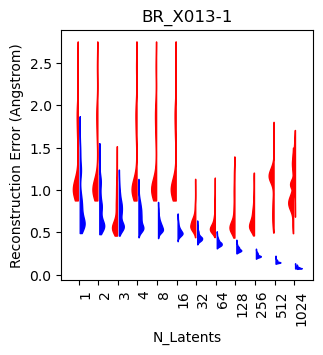

OX_X013-2


<Figure size 640x480 with 0 Axes>

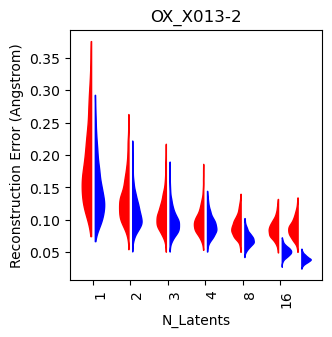

DA_X013-2


<Figure size 640x480 with 0 Axes>

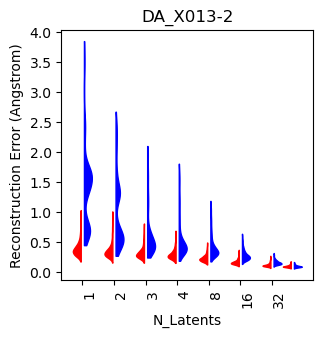

DA_stretch_X013-2


<Figure size 640x480 with 0 Axes>

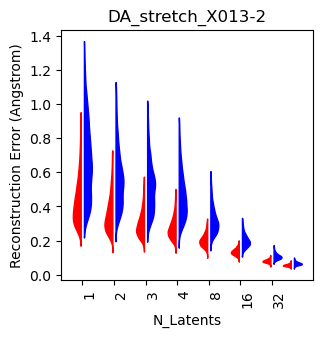

CR_X013-2


<Figure size 640x480 with 0 Axes>

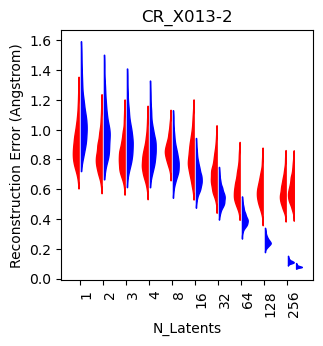

BR_X013-2


<Figure size 640x480 with 0 Axes>

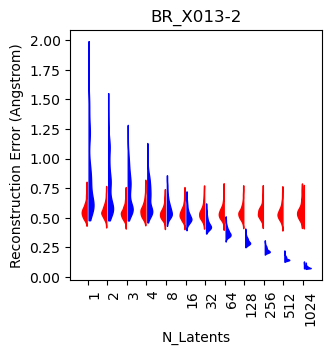

OX_X013-3


<Figure size 640x480 with 0 Axes>

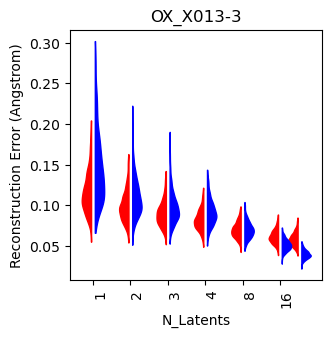

DA_X013-3


<Figure size 640x480 with 0 Axes>

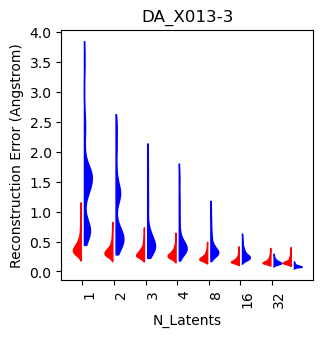

DA_stretch_X013-3


<Figure size 640x480 with 0 Axes>

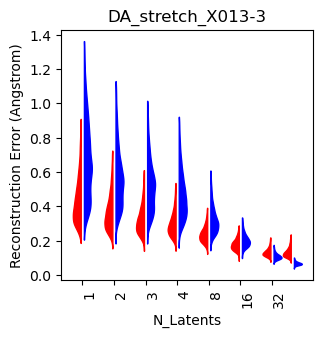

CR_X013-3


<Figure size 640x480 with 0 Axes>

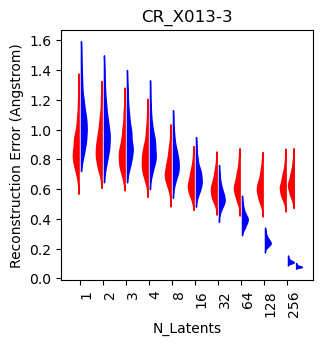

BR_X013-3


<Figure size 640x480 with 0 Axes>

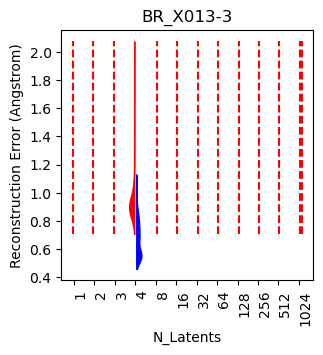

OX_X013-4


<Figure size 640x480 with 0 Axes>

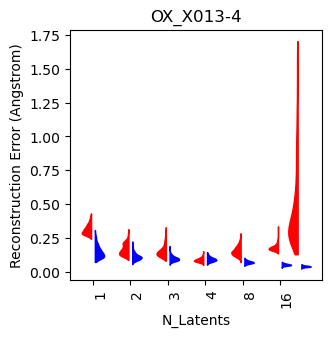

DA_X013-4


<Figure size 640x480 with 0 Axes>

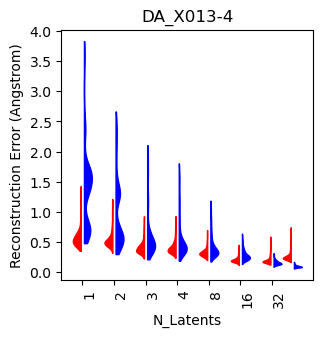

DA_stretch_X013-4


<Figure size 640x480 with 0 Axes>

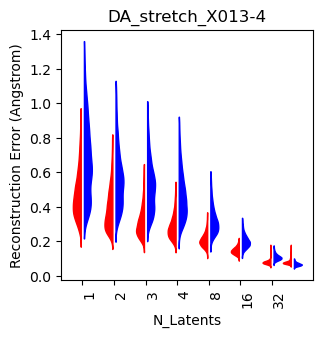

CR_X013-4


<Figure size 640x480 with 0 Axes>

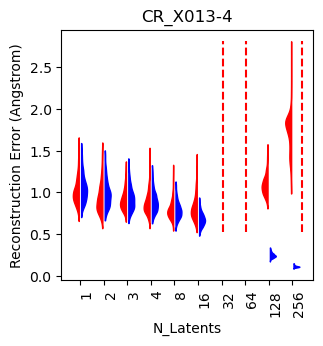

BR_X013-4


<Figure size 640x480 with 0 Axes>

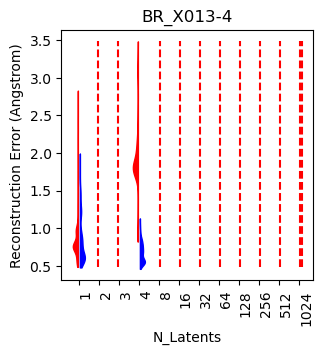

In [7]:
show = True

for base_model in base_models:
    for model_pre in model_prefixes:
        model_name2load = model_pre + base_model
        print(model_name2load)
        chart_data = load_files(glob.glob(f'numpy_backups/{model_name2load}/*/*/*.npy'), verbose=False)
        means, best_rpts_rmsd, best_rpts_loss = lowest_rpts(chart_data)
        
        vae_rmsds =      {key: val[best_rpts_rmsd[key]]['VAE_RMSD']      for key, val in chart_data.items()}
        vae_loss_rmsds = {key: val[best_rpts_loss[key]]['VAE_LOSS_RMSD'] for key, val in chart_data.items()}
        pca_rmsds =      {key: val[best_rpts_rmsd[key]]['PCA_RMSD']      for key, val in chart_data.items()}
        pca_loss_rmsds = {key: val[best_rpts_loss[key]]['PCA_LOSS_RMSD'] for key, val in chart_data.items()}
        
        latents = [int(key) for key in vae_rmsds]
    
        figure_dir = os.path.join(os.getcwd(), f'figures/{model_name2load}/')
        if not os.path.isdir(figure_dir):
            os.makedirs(figure_dir, exist_ok=True)
        
        _ = violin_plots(vae_rmsds, pca_rmsds, latents, model_name2load,
                         ceil=10.0, num_stds=3, show=True, figure_dir=figure_dir)